In [1]:
!pip install transformers accelerate bitsandbytes scipy scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.4 MB/s eta 0:00:00:00:0100:01


In [2]:
import shutil, os, json, warnings, zipfile, sys
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
warnings.filterwarnings('ignore')

DATASET_PATH = "/kaggle/input/datasets/pramukhswami/dna-detectllm-orig"

def _setup_dna_module():
    for root, dirs, files in os.walk(DATASET_PATH):
        if 'dna_detectllm' in dirs:
            src = os.path.join(root, 'dna_detectllm')
            shutil.copytree(src, 'dna_detectllm', dirs_exist_ok=True)
            print(f'Copied from: {src}')
            return
        for fname in files:
            if fname == 'dna_detectllm.zip':
                with zipfile.ZipFile(os.path.join(root, fname)) as zf:
                    zf.extractall('.')
                print(f'Extracted zip')
                return

if not os.path.exists('dna_detectllm'):
    _setup_dna_module()

sys.path.insert(0, os.getcwd())
# Import only — we do NOT modify these functions
from dna_detectllm.metrics import sum_perplexity, entropy
os.environ['HF_TOKEN'] = 'YOUR_HF_TOKEN'

DEVICE_1 = 'cuda:0'
DEVICE_2 = 'cuda:1' if torch.cuda.device_count() > 1 else 'cuda:0'
print(f'GPUs: {torch.cuda.device_count()}')


Copied from: /kaggle/input/datasets/pramukhswami/dna-detectllm-orig/dna_detectllm
GPUs: 2


In [3]:
!mkdir -p data
BASE = "https://raw.githubusercontent.com/Xiaoweizhu57/DNA-DetectLLM/main/Data"
!wget -q -O data/xsum_human.json   "{BASE}/Collected%20data/xsum_human.json"
!wget -q -O data/gpt4_machine.json "{BASE}/Collected%20data/GPT4_machine_test.json"

def load_texts(path):
    with open(path) as f:
        data = json.load(f)
    if isinstance(data, dict):
        for k in ["human_text", "machine_text", "text", "texts"]:
            if k in data: return data[k]
        first = list(data.keys())[0]
        if isinstance(data[first], list): return data[first]
    if isinstance(data, list):
        if isinstance(data[0], str): return data
        if isinstance(data[0], dict) and "text" in data[0]:
            return [d["text"] for d in data]
    raise ValueError(f"Cannot parse {path}")

N = 150
human_texts = load_texts("data/xsum_human.json")[:N]
ai_texts    = load_texts("data/gpt4_machine.json")[:N]
print(f"Human: {len(human_texts)} | AI: {len(ai_texts)}")


Human: 150 | AI: 150


In [4]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)
observer = AutoModelForCausalLM.from_pretrained(
    "tiiuae/falcon-7b", quantization_config=quant_config,
    device_map={"": DEVICE_1}, low_cpu_mem_usage=True)
performer = AutoModelForCausalLM.from_pretrained(
    "tiiuae/falcon-7b-instruct", quantization_config=quant_config,
    device_map={"": DEVICE_2}, low_cpu_mem_usage=True)
observer.eval(); performer.eval()

tokenizer = AutoTokenizer.from_pretrained("tiiuae/falcon-7b")
tokenizer.pad_token = tokenizer.eos_token
MAX_LEN = 512

print(f"GPU 0: {torch.cuda.memory_allocated(0)/1e9:.1f} GB")
print(f"GPU 1: {torch.cuda.memory_allocated(1)/1e9:.1f} GB")


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.word_embeddings.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


...

generation_config.json:   0%|          | 0.00/117 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/281 [00:00<?, ?B/s]

GPU 0: 4.9 GB
GPU 1: 4.9 GB


## Scoring Functions

Two scoring functions defined here in the notebook — the original DNA-DetectLLM and the new
attention-weighted (PAWN-inspired) version. Neither modifies the imported codebase.

**Standard R(s):** Weights all token positions uniformly (1/L).

**PAWN R(s):** Weights each position by the entropy of the performer model's distribution at that
position. Positions where the model is more uncertain carry more weight — those positions are
more informative about whether text is AI-generated or human-written.


In [5]:
# ── Standard scoring (uses imported functions from dna_detectllm) ────────────
@torch.inference_mode()
def compute_score_standard(text, max_len=MAX_LEN):
    enc = tokenizer(text, return_tensors="pt", truncation=True,
                    max_length=max_len, return_token_type_ids=False)
    obs_logits  = observer(**enc.to(DEVICE_1)).logits.float()
    perf_logits = performer(**enc.to(DEVICE_2)).logits.float()
    ppl   = sum_perplexity(enc.to(perf_logits.device), perf_logits)
    x_ppl = entropy(obs_logits.to(DEVICE_1), perf_logits.to(DEVICE_1),
                    enc.to(DEVICE_1), tokenizer.pad_token_id)
    return float(ppl[0] / (2 * x_ppl[0]))


# ── PAWN-inspired scoring (defined entirely here, no codebase changes) ───────
@torch.inference_mode()
def compute_score_pawn(text, max_len=MAX_LEN):
    """
    Attention-weighted R(s) — CONSISTENT weighting for numerator AND denominator.
    Instead of uniform 1/L averaging over positions, each token position is
    weighted by the entropy of the performer's predictive distribution at that
    position.  High-entropy positions (model is uncertain) carry more weight.

    Fix: the x_ppl (cross-perplexity denominator) is now ALSO computed with the
    same positional entropy weights, eliminating the numerator/denominator
    mismatch that caused AUROC to drop in the previous version.

    Reference idea: Miralles-Gonzalez et al. 2025 (PAWN, Information Fusion).
    """
    enc = tokenizer(text, return_tensors="pt", truncation=True,
                    max_length=max_len, return_token_type_ids=False)
    obs_logits  = observer(**enc.to(DEVICE_1)).logits.float()
    perf_logits = performer(**enc.to(DEVICE_2)).logits.float()

    # Move everything to DEVICE_1 for computation
    obs_logits_d  = obs_logits.to(DEVICE_1)
    perf_logits_d = perf_logits.to(DEVICE_1)

    # ---- Shifted logits for next-token prediction (positions 0..L-2 → tokens 1..L-1) ----
    shifted_logits = perf_logits_d[..., :-1, :]        # (1, L-1, V)
    attention      = enc.attention_mask[..., 1:].to(DEVICE_1)  # (1, L-1)
    labels_std     = enc.input_ids[..., 1:].to(DEVICE_1)
    labels_max     = torch.argmax(shifted_logits, dim=-1)

    # ---- Per-position entropy of performer distribution: H_i = -sum p log p ----
    probs    = torch.softmax(shifted_logits, dim=-1)           # (1, L-1, V)
    pos_ent  = -(probs * torch.log(probs + 1e-9)).sum(dim=-1)  # (1, L-1)

    # Normalize to weights that sum to 1 over valid (non-padding) positions
    pos_ent_masked = pos_ent * attention
    weights = pos_ent_masked / (pos_ent_masked.sum(dim=1, keepdim=True) + 1e-9)  # (1, L-1)

    # ---- NUMERATOR: weighted CE for standard tokens and greedy tokens ----
    logits_T = shifted_logits.transpose(1, 2)                  # (1, V, L-1)
    ce_std = F.cross_entropy(logits_T, labels_std, reduction='none')  # (1, L-1)
    ce_max = F.cross_entropy(logits_T, labels_max, reduction='none')

    ppl_std_w = (ce_std * weights).sum(dim=1)   # scalar per sample
    ppl_max_w = (ce_max * weights).sum(dim=1)

    # ---- DENOMINATOR: weighted cross-perplexity H(observer, performer) ----
    # Reimplemented here with the SAME positional entropy weights.
    # This mirrors what entropy() does but on shifted positions with weighted avg.
    #
    # entropy() computes: target = softmax(p_logits), ce = CE(q_scores, target)
    # where CE with soft targets = -sum(target * log_softmax(input))
    # We replicate this on shifted positions (:-1) to align with the numerator.

    vocab_size = obs_logits_d.shape[-1]
    # Observer (p) softmax distribution at positions 0..L-2
    p_i = F.softmax(obs_logits_d[:, :-1, :], dim=-1)       # (1, L-1, V)
    # Performer (q) log-softmax at positions 0..L-2
    log_q_i = F.log_softmax(perf_logits_d[:, :-1, :], dim=-1)  # (1, L-1, V)
    # Per-position cross-entropy H(p, q)_i = -sum_v p_v * log q_v
    ce_cross = -(p_i * log_q_i).sum(dim=-1)                # (1, L-1)

    # Apply the SAME entropy-based positional weights
    x_ppl_w = (ce_cross * weights).sum(dim=1)               # scalar per sample

    return float((ppl_std_w + ppl_max_w).cpu() / (2 * x_ppl_w.cpu() + 1e-9))


def score_list(texts, fn, desc, max_len=MAX_LEN):
    scores = []
    for t in tqdm(texts, desc=desc):
        try:    scores.append(fn(t, max_len=max_len))
        except: scores.append(float('nan'))
    return scores


# Sanity check both functions on same text
s1 = compute_score_standard("hello world")
s2 = compute_score_pawn("hello world")
print(f"Standard R(s): {s1:.4f}")
print(f"PAWN     R(s): {s2:.4f}")

Standard R(s): 0.8342
PAWN     R(s): 0.7181


In [6]:
print("Scoring with STANDARD R(s)...")
h_std = score_list(human_texts, compute_score_standard, "Human-std")
a_std = score_list(ai_texts,    compute_score_standard, "AI-std")

print("\nScoring with PAWN R(s)...")
h_pawn = score_list(human_texts, compute_score_pawn, "Human-pawn")
a_pawn = score_list(ai_texts,    compute_score_pawn, "AI-pawn")

def clean(s): return [x for x in s if x == x]

auroc_std  = roc_auc_score([1]*len(clean(h_std))  + [0]*len(clean(a_std)),
                            clean(h_std) + clean(a_std))
auroc_pawn = roc_auc_score([1]*len(clean(h_pawn)) + [0]*len(clean(a_pawn)),
                            clean(h_pawn) + clean(a_pawn))

print(f"\n{'Method':<12} {'Human mean':>12} {'AI mean':>10} {'Gap':>8} {'AUROC':>8}")
print("-" * 55)
print(f"{'Standard':<12} {np.nanmean(h_std):>12.4f} {np.nanmean(a_std):>10.4f} {np.nanmean(h_std)-np.nanmean(a_std):>8.4f} {auroc_std:>8.4f}")
print(f"{'PAWN':<12} {np.nanmean(h_pawn):>12.4f} {np.nanmean(a_pawn):>10.4f} {np.nanmean(h_pawn)-np.nanmean(a_pawn):>8.4f} {auroc_pawn:>8.4f}")


Scoring with STANDARD R(s)...


AI-std: 100%|██████████| 150/150 [04:13<00:00,  1.69s/it]



Scoring with PAWN R(s)...


AI-pawn: 100%|██████████| 150/150 [04:11<00:00,  1.68s/it]


Method         Human mean    AI mean      Gap    AUROC
-------------------------------------------------------
Standard           0.6944     0.5968   0.0976   0.9965
PAWN               0.7005     0.6201   0.0804   0.9912


In [7]:
# Score same texts truncated to different token lengths
# This is where PAWN should help most — at 40 tokens, standard AUROC is ~82%
TOKEN_LENGTHS = [40, 80, 120, 200, 512]

results = {}
for max_len in TOKEN_LENGTHS:
    hs = score_list(human_texts, compute_score_standard, f"H-std-{max_len}", max_len=max_len)
    as_ = score_list(ai_texts,   compute_score_standard, f"A-std-{max_len}", max_len=max_len)
    hp = score_list(human_texts, compute_score_pawn,     f"H-pawn-{max_len}", max_len=max_len)
    ap = score_list(ai_texts,    compute_score_pawn,     f"A-pawn-{max_len}", max_len=max_len)

    auc_s = roc_auc_score([1]*len(clean(hs)) + [0]*len(clean(as_)), clean(hs)+clean(as_))
    auc_p = roc_auc_score([1]*len(clean(hp)) + [0]*len(clean(ap)), clean(hp)+clean(ap))
    results[max_len] = dict(h_std=hs, a_std=as_, h_pawn=hp, a_pawn=ap,
                            auroc_std=auc_s, auroc_pawn=auc_p)
    print(f"Tokens={max_len:<4}  Standard AUROC={auc_s:.4f}  PAWN AUROC={auc_p:.4f}  Δ={auc_p-auc_s:+.4f}")


A-pawn-40: 100%|██████████| 150/150 [01:51<00:00,  1.34it/s]


Tokens=40    Standard AUROC=0.8064  PAWN AUROC=0.7389  Δ=-0.0675


A-pawn-80: 100%|██████████| 150/150 [02:19<00:00,  1.08it/s]


Tokens=80    Standard AUROC=0.9116  PAWN AUROC=0.8627  Δ=-0.0490


A-pawn-120: 100%|██████████| 150/150 [02:22<00:00,  1.05it/s]


Tokens=120   Standard AUROC=0.9523  PAWN AUROC=0.9181  Δ=-0.0342


A-pawn-200: 100%|██████████| 150/150 [02:53<00:00,  1.16s/it]


Tokens=200   Standard AUROC=0.9865  PAWN AUROC=0.9711  Δ=-0.0154


A-pawn-512: 100%|██████████| 150/150 [04:11<00:00,  1.68s/it]

Tokens=512   Standard AUROC=0.9965  PAWN AUROC=0.9912  Δ=-0.0052


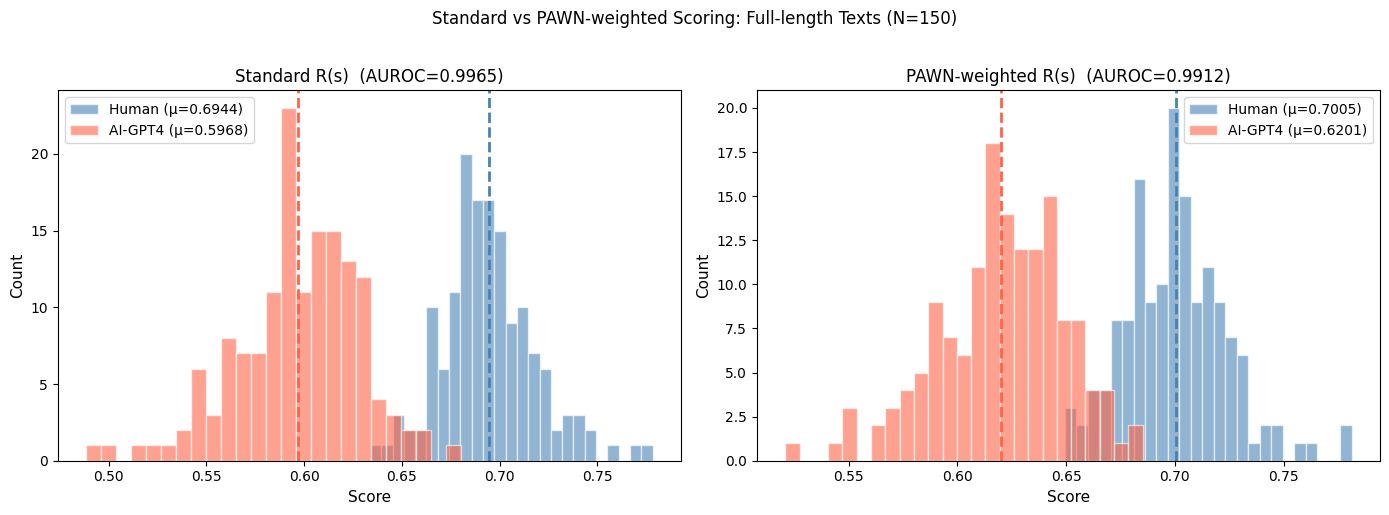

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (h, a, label, auroc) in zip(axes, [
    (clean(h_std),  clean(a_std),  'Standard R(s)',      auroc_std),
    (clean(h_pawn), clean(a_pawn), 'PAWN-weighted R(s)', auroc_pawn),
]):
    ax.hist(h, bins=25, alpha=0.6, color='steelblue', edgecolor='white',
            label=f'Human (μ={np.mean(h):.4f})')
    ax.hist(a, bins=25, alpha=0.6, color='tomato', edgecolor='white',
            label=f'AI-GPT4 (μ={np.mean(a):.4f})')
    ax.axvline(np.mean(h), color='steelblue', ls='--', lw=2)
    ax.axvline(np.mean(a), color='tomato',    ls='--', lw=2)
    ax.set_title(f'{label}  (AUROC={auroc:.4f})', fontsize=12)
    ax.set_xlabel('Score', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.legend(fontsize=10)

plt.suptitle('Standard vs PAWN-weighted Scoring: Full-length Texts (N=150)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('pawn_distributions_full.png', dpi=150, bbox_inches='tight')
plt.show()


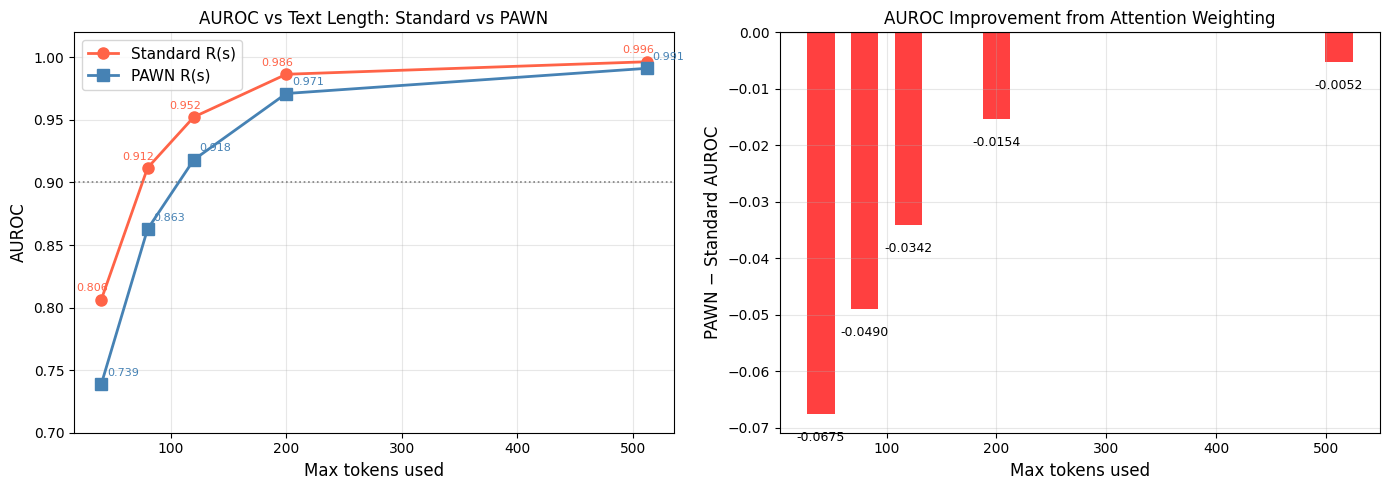

In [9]:
lens   = TOKEN_LENGTHS
aucs_s = [results[l]['auroc_std']  for l in lens]
aucs_p = [results[l]['auroc_pawn'] for l in lens]
deltas = [p - s for s, p in zip(aucs_s, aucs_p)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lens, aucs_s, 'o-', color='tomato',     lw=2, ms=8, label='Standard R(s)')
axes[0].plot(lens, aucs_p, 's-', color='steelblue',  lw=2, ms=8, label='PAWN R(s)')
for l, s, p in zip(lens, aucs_s, aucs_p):
    axes[0].annotate(f'{s:.3f}', (l, s), textcoords="offset points", xytext=(-18,  6), fontsize=8, color='tomato')
    axes[0].annotate(f'{p:.3f}', (l, p), textcoords="offset points", xytext=( 4,  6), fontsize=8, color='steelblue')
axes[0].set_xlabel('Max tokens used', fontsize=12)
axes[0].set_ylabel('AUROC', fontsize=12)
axes[0].set_title('AUROC vs Text Length: Standard vs PAWN', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].set_ylim(0.7, 1.02)
axes[0].axhline(0.9, color='grey', ls=':', lw=1.2, label='0.9 baseline')
axes[0].grid(alpha=0.3)

colors_d = ['green' if d > 0 else 'red' for d in deltas]
bars = axes[1].bar(lens, deltas, color=colors_d, alpha=0.75, width=25)
axes[1].axhline(0, color='black', lw=1.5)
for bar, d in zip(bars, deltas):
    axes[1].text(bar.get_x() + bar.get_width()/2, d + (0.001 if d >= 0 else -0.003),
                 f'{d:+.4f}', ha='center', va='bottom' if d >= 0 else 'top', fontsize=9)
axes[1].set_xlabel('Max tokens used', fontsize=12)
axes[1].set_ylabel('PAWN − Standard AUROC', fontsize=12)
axes[1].set_title('AUROC Improvement from Attention Weighting', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pawn_auroc_vs_length.png', dpi=150)
plt.show()


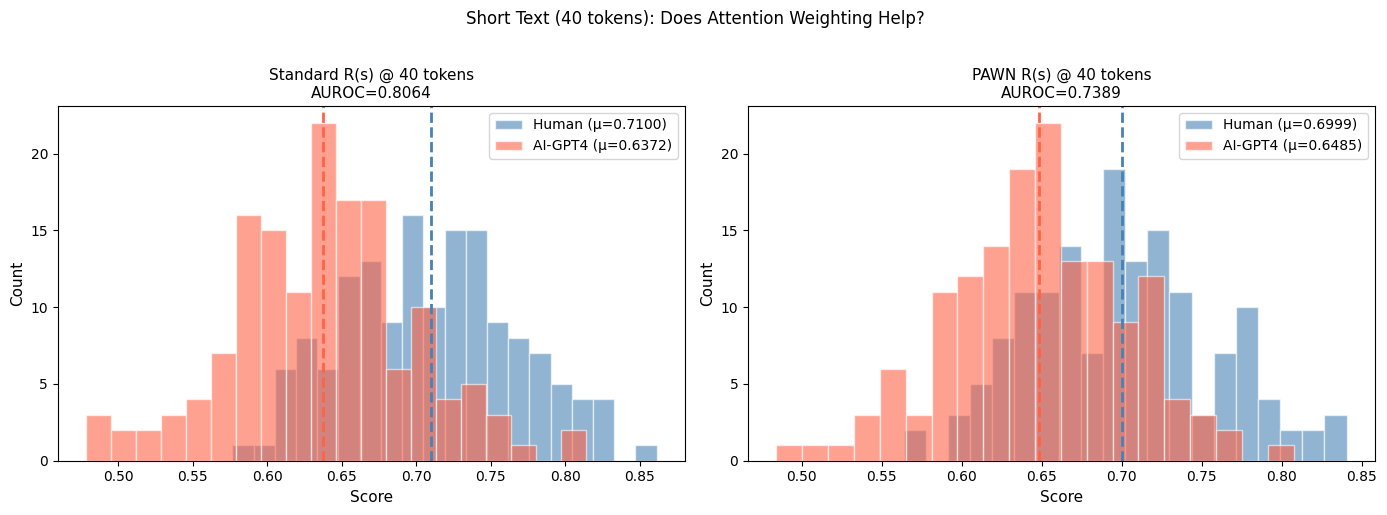

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (h, a, label, auroc) in zip(axes, [
    (clean(results[40]['h_std']),  clean(results[40]['a_std']),
     'Standard R(s) @ 40 tokens', results[40]['auroc_std']),
    (clean(results[40]['h_pawn']), clean(results[40]['a_pawn']),
     'PAWN R(s) @ 40 tokens',     results[40]['auroc_pawn']),
]):
    ax.hist(h, bins=20, alpha=0.6, color='steelblue', edgecolor='white',
            label=f'Human (μ={np.mean(h):.4f})')
    ax.hist(a, bins=20, alpha=0.6, color='tomato', edgecolor='white',
            label=f'AI-GPT4 (μ={np.mean(a):.4f})')
    ax.axvline(np.mean(h), color='steelblue', ls='--', lw=2)
    ax.axvline(np.mean(a), color='tomato',    ls='--', lw=2)
    ax.set_title(f'{label}\nAUROC={auroc:.4f}', fontsize=11)
    ax.set_xlabel('Score', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.legend(fontsize=10)

plt.suptitle('Short Text (40 tokens): Does Attention Weighting Help?', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('pawn_short_text_40.png', dpi=150, bbox_inches='tight')
plt.show()


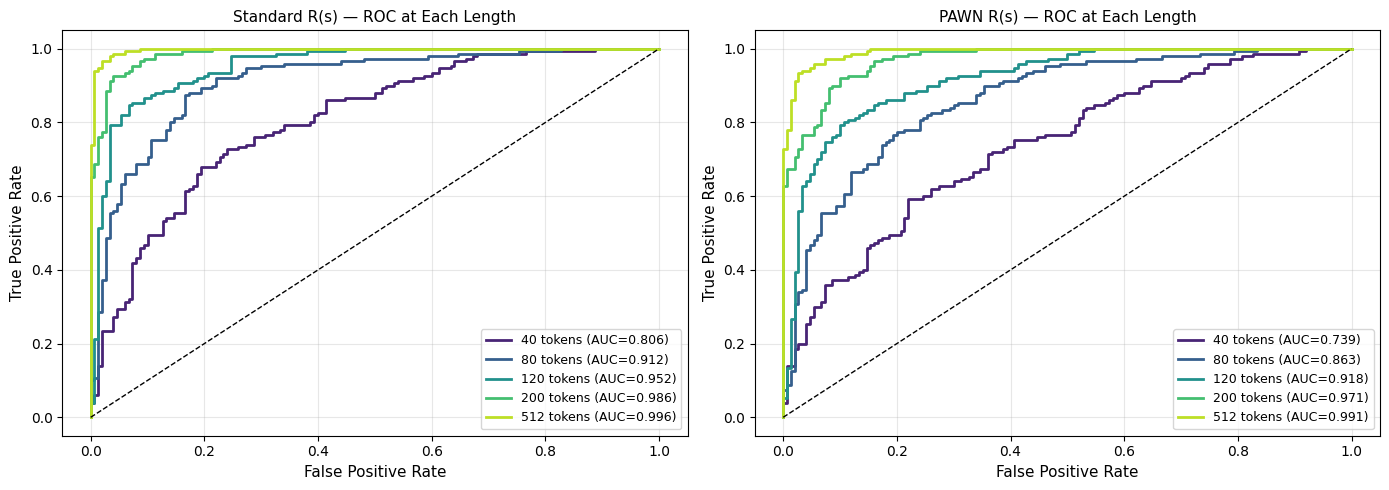

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_len = plt.cm.viridis(np.linspace(0.1, 0.9, len(TOKEN_LENGTHS)))

for ax, method_key, title in [
    (axes[0], 'std',  'Standard R(s) — ROC at Each Length'),
    (axes[1], 'pawn', 'PAWN R(s) — ROC at Each Length'),
]:
    for i, l in enumerate(TOKEN_LENGTHS):
        h = clean(results[l][f'h_{method_key}'])
        a = clean(results[l][f'a_{method_key}'])
        y_true  = [1]*len(h) + [0]*len(a)
        y_score = h + a
        fpr, tpr, _ = roc_curve(y_true, y_score)
        auc_val = results[l][f'auroc_{method_key}']
        ax.plot(fpr, tpr, color=colors_len[i], lw=2, label=f'{l} tokens (AUC={auc_val:.3f})')
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pawn_roc_curves.png', dpi=150)
plt.show()


In [12]:
output = {
    "experiment": "Token Independence / PAWN-weighted Scoring",
    "method": "Attention-weighted R(s) — position weights = softmax(per-position entropy)",
    "n": N,
    "full_length": {
        "standard_auroc":  auroc_std,
        "pawn_auroc":      auroc_pawn,
        "delta":           auroc_pawn - auroc_std,
        "human_mean_std":  float(np.nanmean(h_std)),
        "ai_mean_std":     float(np.nanmean(a_std)),
        "human_mean_pawn": float(np.nanmean(h_pawn)),
        "ai_mean_pawn":    float(np.nanmean(a_pawn)),
    },
    "by_length": {
        str(l): {
            "auroc_standard": results[l]['auroc_std'],
            "auroc_pawn":     results[l]['auroc_pawn'],
            "delta":          results[l]['auroc_pawn'] - results[l]['auroc_std'],
        }
        for l in TOKEN_LENGTHS
    }
}

with open("pawn_results.json", "w") as f:
    json.dump(output, f, indent=2)

print(json.dumps({k: v for k, v in output.items() if k != 'by_length'}, indent=2))
print()
print(f"{'Tokens':<8} {'Standard':>10} {'PAWN':>10} {'Delta':>8}")
for l in TOKEN_LENGTHS:
    d = output['by_length'][str(l)]
    print(f"{l:<8} {d['auroc_standard']:>10.4f} {d['auroc_pawn']:>10.4f} {d['delta']:>+8.4f}")


{
  "experiment": "Token Independence / PAWN-weighted Scoring",
  "method": "Attention-weighted R(s) \u2014 position weights = softmax(per-position entropy)",
  "n": 150,
  "full_length": {
    "standard_auroc": 0.9964888888888889,
    "pawn_auroc": 0.9912444444444444,
    "delta": -0.005244444444444496,
    "human_mean_std": 0.6943720257282258,
    "ai_mean_std": 0.5967805935939153,
    "human_mean_pawn": 0.7005097858111063,
    "ai_mean_pawn": 0.6200785672664643
  }
}

Tokens     Standard       PAWN    Delta
40           0.8064     0.7389  -0.0675
80           0.9116     0.8627  -0.0490
120          0.9523     0.9181  -0.0342
200          0.9865     0.9711  -0.0154
512          0.9965     0.9912  -0.0052


In [13]:
!ls

data			  pawn_distributions_full.png  pawn_short_text_40.png
dna_detectllm		  pawn_results.json
pawn_auroc_vs_length.png  pawn_roc_curves.png


In [14]:
!mkdir pawn_results_new

In [15]:
!cp -r *.png *.json pawn_results_new
!zip -r pawn_results_new.zip pawn_results_new

  adding: pawn_results_new/ (stored 0%)
  adding: pawn_results_new/pawn_short_text_40.png (deflated 16%)
  adding: pawn_results_new/pawn_results.json (deflated 65%)
  adding: pawn_results_new/pawn_auroc_vs_length.png (deflated 12%)
  adding: pawn_results_new/pawn_roc_curves.png (deflated 13%)
  adding: pawn_results_new/pawn_distributions_full.png (deflated 17%)
